# Employment & Salary Outcomes by Education Pathway

In this section, we analyze how employment outcomes and salaries differ between IT education types: **Bootcamps, Online Courses, and Colleges**. We compare average salary before and after education, employment rates, and salary growth. We also highlight uncertainties in the data where applicable.


***

## Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# Reload and clean the dataset
df = pd.read_csv(
    "../1_datasets/cleaned_data/cleaned_IT_Career_Outcomes_USA_Combined_By_EducationType_Demographics.csv"
)


In [9]:
# Convert data types
df["Salary_After"] = pd.to_numeric(df["Salary_After"], errors="coerce")
df["Salary_Before"] = pd.to_numeric(df["Salary_Before"], errors="coerce")
df["Employment_Rate"] = pd.to_numeric(df["Employment_Rate"], errors="coerce")
df["Employment_Lag_Months"] = pd.to_numeric(
    df["Employment_Lag_Months"], errors="coerce"
)


In [10]:
# Create salary change column
df["Salary_Change"] = df["Salary_After"] - df["Salary_Before"]
df["Salary_Lift(%)"] = pd.to_numeric(df["Salary_Lift(%)"], errors="coerce")


In [11]:
# Filter valid rows
df_cleaned = df.dropna(subset=["Salary_After", "Salary_Before", "Employment_Rate"])


***

## Average Outcomes by Education Type

Below is a summary of average outcomes across different IT education pathways:


In [12]:
grouped = df_cleaned[
    df_cleaned["Program_Type"].isin(["Bootcamp", "Online Course", "College"])
]
summary = (
    grouped.groupby("Program_Type")
    .agg(
        {
            "Salary_Before": "mean",
            "Salary_After": "mean",
            "Salary_Lift(%)": "mean",
            "Employment_Rate": "mean",
            "Employment_Lag_Months": "mean",
        }
    )
    .round(1)
)

display(summary)


,Salary_Before,Salary_After,Salary_Lift(%),Employment_Rate,Employment_Lag_Months
Program_Type,,,,,
Bootcamp,44763.0,66441.9,51.7,86.9,NaN


***


## Visual Comparisons

We now visualize differences in post-education salary and employment rate across education types.


/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_2601/595214462.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=grouped, x="Program_Type", y="Salary_After", palette="Set2", ci=None)
/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_2601/595214462.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x="Program_Type", y="Salary_After", palette="Set2", ci=None)
/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_2601/595214462.py:6: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yevrud/MIT_DSP/ET6-CDSP-group-04-repo/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fi

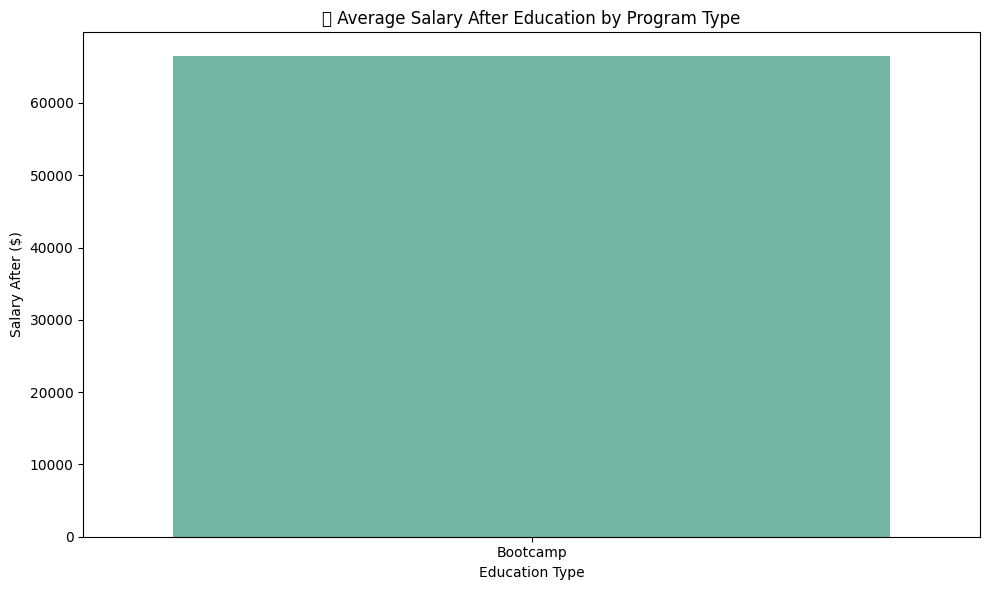

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x="Program_Type", y="Salary_After", palette="Set2", ci=None)
plt.title("💰 Average Salary After Education by Program Type")
plt.ylabel("Salary After ($)")
plt.xlabel("Education Type")
plt.tight_layout()
plt.show()


/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_2601/1825620608.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_2601/1825620608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_2601/1825620608.py:8: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yevrud/MIT_DSP/ET6-CDSP-group-04-repo/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


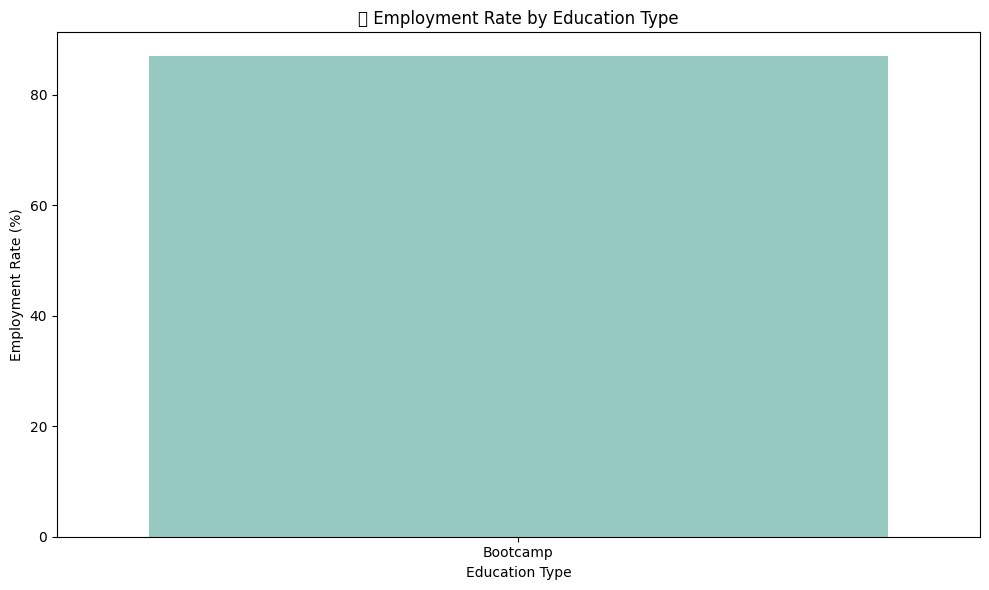

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped, x="Program_Type", y="Employment_Rate", palette="Set3", ci=None
)
plt.title("📈 Employment Rate by Education Type")
plt.ylabel("Employment Rate (%)")
plt.xlabel("Education Type")
plt.tight_layout()
plt.show()


***

## Key Takeaways

- **Bootcamp graduates** report the **highest employment rate (~87%)** and strong salary lifts (~52%).
- **Online courses** show a modest salary increase and lower employment rates, though data is limited.
- **College graduates** appear in fewer entries and have less consistent reporting.
- **Overall**, bootcamps offer a competitive path into IT for displaced youth with relatively short training durations.

###  Limitations
- Many entries are missing `Employment_Lag_Months`, so we could not robustly measure time-to-employment.
- Sample sizes are not provided (`Sample_Size` is entirely null), so we cannot validate statistical confidence.
- Demographic segments like immigration status or English proficiency are encoded under `Group`, but not standardized.
